## What is the most optimal skill to learn for Data Analysts? 

#### Methodology
1. Group skills to determine median salary and likelyhood of being in posting
2. Visualize median salary vs percentage skill demand
3. (OPtional) Determine if certain technologies are more prevalent

In [27]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
df_DA_INA = df[(df['job_country'] == 'Indonesia') & (df['job_title_short'] == 'Data Analyst')].copy()

In [35]:
df_DA_INA = df_DA_INA.dropna(subset='salary_year_avg')

df_DA_INA_Exploded = df_DA_INA.explode('job_skills')

df_DA_INA_Exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [ ]:
df_DA_skills = df_DA_INA_Exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(ascending=False, by='count')

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

DA_job_count = len(df_DA_INA)

df_DA_skills['skill_percentage'] = df_DA_skills['skill_count'] / DA_job_count * 100

skill_percent = 5

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percentage'] > skill_percent]

df_DA_skills_high_demand

,skill_count,median_salary,skill_percentage
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


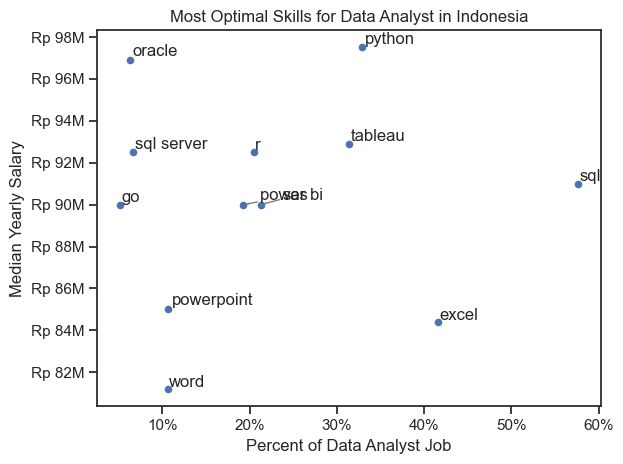

In [67]:
from adjustText import adjust_text

df_DA_skills_high_demand.plot(kind='scatter', x = 'skill_percentage', y = 'median_salary') 

texts = []

for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percentage'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.xlabel('Percent of Data Analyst Job')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analyst in Indonesia')

from matplotlib.ticker import PercentFormatter

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'Rp {int(y/1000)}M'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()

In [59]:
df_technology = df['job_type_skills'].copy()

# remove duplicate 
df_technology.drop_duplicates(inplace=True)

# remove Nan values
df_technology.dropna(inplace=True)

# combine dictionary into one 
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)        # conver str into dict
    for key, value in row_dict.items():
        if key in technology_dict:          # if key already exist in dict, add value to existing value
            technology_dict[key] += value
        else:                               # if key does not exist in dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list 
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['outlook',
  'nuix',
  'spss',
  'ms access',
  'sharepoint',
  'splunk',
  'dax',
  'qlik',
  'esquisse',
  'tableau',
  'powerpoint',
  'ssrs',
  'powerbi',
  'ssis',
  'sap',
  'visio',
  'looker',
  'sheets',
  'msaccess',
  'alteryx',
  'cognos',
  'power bi',
  'microstrategy',
  'word',
  'excel',
  'spreadsheet',
  'datarobot',
  'sas'],
 'programming': ['shell',
  'bash',
  'f#',
  'visual basic',
  'apl',
  'sass',
  'cobol',
  'haskell',
  'no-sql',
  'c',
  'css',
  'crystal',
  'visualbasic',
  'java',
  't-sql',
  'ruby',
  'pascal',
  'perl',
  'assembly',
  'mongodb',
  'php',
  'golang',
  'delphi',
  'javascript',
  'sql',
  'mongo',
  'c#',
  'r',
  'julia',
  'go',
  'python',
  'groovy',
  'clojure',
  'erlang',
  'ocaml',
  'kotlin',
  'rust',
  'html',
  'sas',
  'lua',
  'swift',
  'objective-c',
  'fortran',
  'dart',
  'elixir',
  'lisp',
  'solidity',
  'powershell',
  'vba',
  'nosql',
  'matlab',
  'vb.net',
  'typescript',
  'scala',
  '

In [60]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,outlook
0,analyst_tools,nuix
0,analyst_tools,spss
0,analyst_tools,ms access
0,analyst_tools,sharepoint
...,...,...
9,sync,rocketchat
9,sync,unify
9,sync,ringcentral
9,sync,google chat


In [62]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

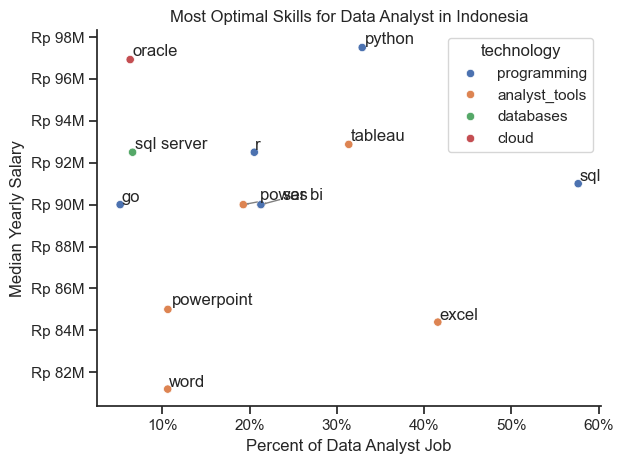

In [66]:
from adjustText import adjust_text

sns.scatterplot(
    data = df_plot,
    x = 'skill_percentage',
    y = 'median_salary',
    hue ='technology'
)

sns.despine()
sns.set_theme(style='ticks')

texts = []

for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percentage'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.xlabel('Percent of Data Analyst Job')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analyst in Indonesia')

from matplotlib.ticker import PercentFormatter

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'Rp {int(y/1000)}M'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()